# Kmitanie mechanickej sústavy

Kmitanie je periodický pohyb telesa okolo rovnovážnej polohy. V strojárstve sa stretávame s kmitaním pri vibráciách motorov, podvozkov vozidiel, mostov či strojných súčastí. Pochopenie tlmeného kmitania je kľúčové pri návrhu tlmičov a pružín.

V tomto notebooku riešime pohybovú rovnicu tlmeného harmonického oscilátora numericky pomocou knižnice SciPy.

## Teoretický základ

Pohybová rovnica tlmeného harmonického oscilátora:

$$m \cdot \ddot{x} + b \cdot \dot{x} + k \cdot x = 0$$

kde:
- $m$ – hmotnosť telesa [kg]
- $b$ – koeficient tlmenia [N·s/m]
- $k$ – tuhosť pružiny [N/m]
- $x$ – výchylka od rovnovážnej polohy [m]

**Vlastná uhlová frekvencia:**
$$\omega_0 = \sqrt{\frac{k}{m}}$$

**Kritické tlmenie:**
$$b_{krit} = 2 \cdot \sqrt{k \cdot m}$$

Podľa pomeru $b$ a $b_{krit}$ rozlišujeme tri režimy:

| Režim | Podmienka | Popis |
|-------|-----------|-------|
| Podtlmený | $b < b_{krit}$ | Sústava kmitá s klesajúcou amplitúdou |
| Kriticky tlmený | $b = b_{krit}$ | Najrýchlejší návrat bez kmitania |
| Pretlmený | $b > b_{krit}$ | Pomalý návrat bez kmitania |

## Simulácia tlmeného oscilátora

Nasledujúci kód numericky rieši pohybovú rovnicu pomocou SciPy a vykreslí výchylku, rýchlosť, fázový diagram a porovnanie troch režimov tlmenia.

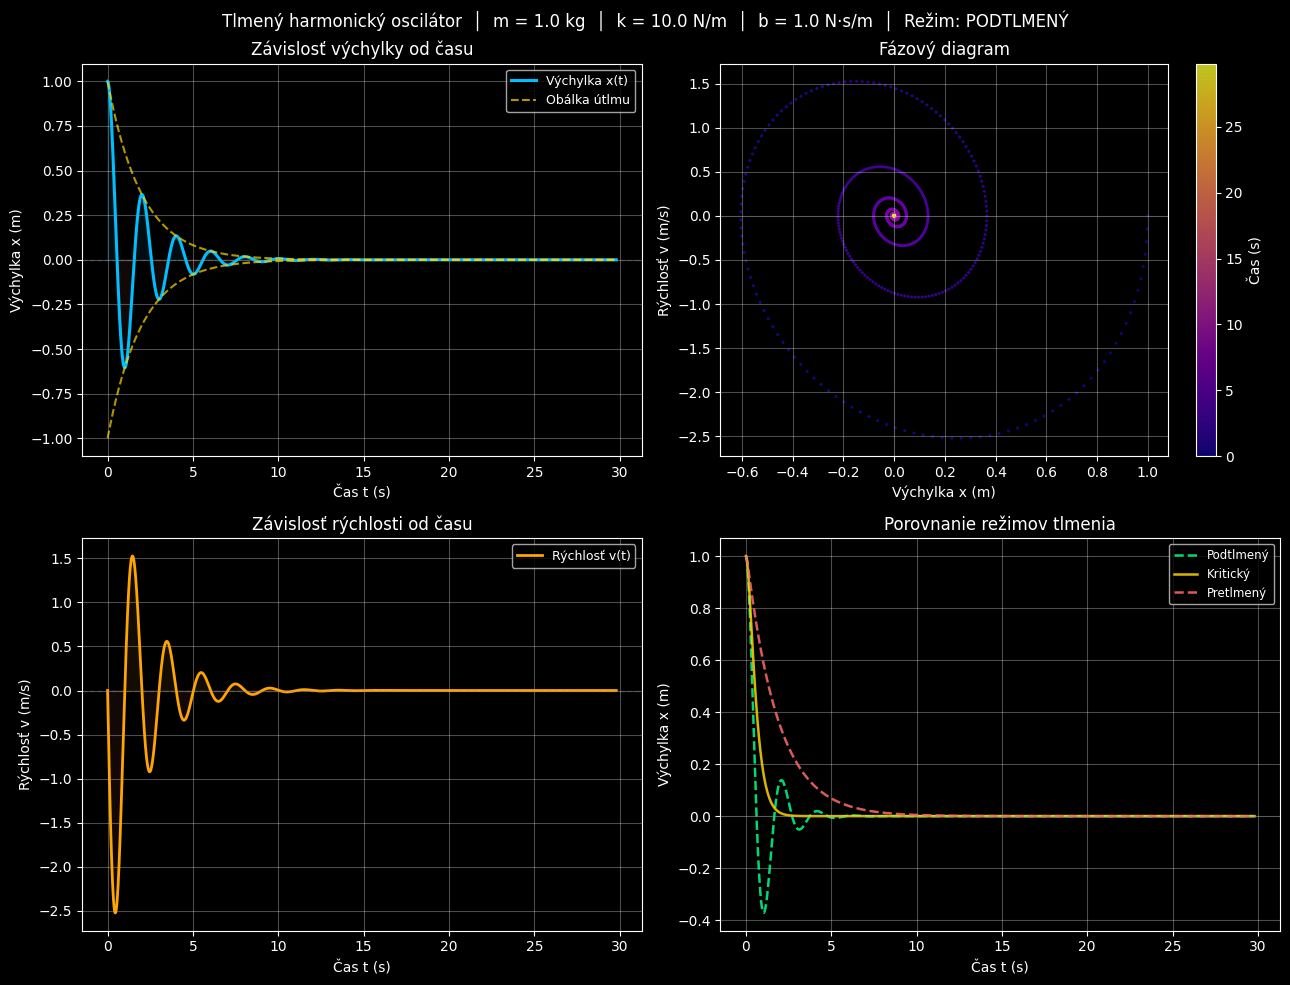

Vlastná frekvencia:    3.162 rad/s  (0.503 Hz)
Kritické tlmenie:      6.32 N·s/m
Pomer b/b_krit:        0.158
Režim tlmenia:         PODTLMENÝ


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parametre sústavy
m  = 1.0     # hmotnosť v kg
k  = 10.0    # tuhosť pružiny v N/m
b  = 1.0     # koeficient tlmenia v N·s/m
x0 = 1.0     # počiatočná výchylka v m
v0 = 0.0     # počiatočná rýchlosť v m/s

# Vypočítame kritické tlmenie a vlastnú frekvenciu
b_krit = 2 * np.sqrt(k * m)
omega0 = np.sqrt(k / m)
pomer  = b / b_krit

# Určenie režimu tlmenia
if pomer < 0.99:
    rezim = 'PODTLMENÝ'
elif pomer <= 1.01:
    rezim = 'KRITICKY TLMENÝ'
else:
    rezim = 'PRETLMENÝ'

# Pohybová rovnica pre SciPy solve_ivp
def pohybova_rovnica(t, y):
    x, v = y
    dxdt = v
    dvdt = (-b * v - k * x) / m
    return [dxdt, dvdt]

# Časový rozsah simulácie
T_kyvov = 2 * np.pi / omega0
t_max   = max(15 * T_kyvov, 5)
t_eval  = np.linspace(0, t_max, 2000)

# Numerické riešenie
sol = solve_ivp(
    pohybova_rovnica,
    (0, t_max),
    [x0, v0],
    t_eval=t_eval,
    method='RK45',
    rtol=1e-8
)

t = sol.t
x = sol.y[0]
v = sol.y[1]

# Obálka útlmu pre podtlmený režim
if pomer < 1:
    alpha  = b / (2 * m)
    obalka = x0 * np.exp(-alpha * t)

# Vykreslenie štyroch grafov
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(13, 10))

# Graf výchylky
ax1.plot(t, x, color='#00BFFF', linewidth=2.2, label='Výchylka x(t)')
ax1.axhline(y=0, color='gray', linewidth=1, linestyle='--', alpha=0.3)
if pomer < 1:
    ax1.plot(t,  obalka, color='#FFD700', linewidth=1.5,
             linestyle='--', alpha=0.7, label='Obálka útlmu')
    ax1.plot(t, -obalka, color='#FFD700', linewidth=1.5,
             linestyle='--', alpha=0.7)
ax1.fill_between(t, x, 0, where=(x >= 0), alpha=0.08, color='#00BFFF')
ax1.fill_between(t, x, 0, where=(x < 0), alpha=0.08, color='#FF6B6B')
ax1.set_xlabel('Čas t (s)')
ax1.set_ylabel('Výchylka x (m)')
ax1.set_title('Závislosť výchylky od času')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Fázový diagram
body = ax2.scatter(x, v, c=t, cmap='plasma', s=1.5, alpha=0.8)
ax2.axhline(y=0, color='gray', lw=0.8, alpha=0.3)
ax2.axvline(x=0, color='gray', lw=0.8, alpha=0.3)
ax2.set_xlabel('Výchylka x (m)')
ax2.set_ylabel('Rýchlosť v (m/s)')
ax2.set_title('Fázový diagram')
ax2.grid(True, alpha=0.3)
plt.colorbar(body, ax=ax2, label='Čas (s)')

# Graf rýchlosti
ax3.plot(t, v, color='#FFA500', linewidth=2.0, label='Rýchlosť v(t)')
ax3.axhline(y=0, color='gray', linewidth=1, linestyle='--', alpha=0.3)
ax3.fill_between(t, v, 0, where=(v >= 0), alpha=0.08, color='#FFA500')
ax3.fill_between(t, v, 0, where=(v < 0), alpha=0.08, color='#FF6B6B')
ax3.set_xlabel('Čas t (s)')
ax3.set_ylabel('Rýchlosť v (m/s)')
ax3.set_title('Závislosť rýchlosti od času')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Porovnanie troch režimov
t_por = np.linspace(0, t_max, 2000)
for b_por, farba, nazov in [
    (b_krit * 0.3, '#00FF88', 'Podtlmený'),
    (b_krit * 1.0, '#FFD700', 'Kritický'),
    (b_krit * 3.0, '#FF6B6B', 'Pretlmený')
]:
    sol_por = solve_ivp(
        lambda t, y, b_p=b_por: [y[1], (-b_p * y[1] - k * y[0]) / m],
        (0, t_max), [x0, v0],
        t_eval=t_por, method='RK45'
    )
    ax4.plot(sol_por.t, sol_por.y[0],
             color=farba, linewidth=1.8,
             linestyle='-' if nazov == 'Kritický' else '--',
             label=nazov, alpha=0.85)

ax4.axhline(y=0, color='gray', lw=0.8, alpha=0.3)
ax4.set_xlabel('Čas t (s)')
ax4.set_ylabel('Výchylka x (m)')
ax4.set_title('Porovnanie režimov tlmenia')
ax4.legend(fontsize=8.5)
ax4.grid(True, alpha=0.3)

fig.suptitle(
    f'Tlmený harmonický oscilátor  │  m = {m} kg  │  '
    f'k = {k} N/m  │  b = {b:.1f} N·s/m  │  Režim: {rezim}',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f'Vlastná frekvencia:    {omega0:.3f} rad/s  ({omega0/(2*np.pi):.3f} Hz)')
print(f'Kritické tlmenie:      {b_krit:.2f} N·s/m')
print(f'Pomer b/b_krit:        {pomer:.3f}')
print(f'Režim tlmenia:         {rezim}')

![Kmitanie mechanickej sústavy](_images/tlmeny.png)
*Obr. Tlmený harmonický oscilátor – výchylka, rýchlosť, fázový diagram a porovnanie režimov*